# **Tarea 2: Predicción de redshift fotométrico con métodos de ensamble**
#### Integrantes: Amelia Diaz y Monserrat Zúñiga.



## 1. Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV, cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 20)

## 2. Exploración inicial del conjunto de entrenamiento

Cargamos los tres archivos y hacemos una primera inspección del tamaño, tipos de datos y rangos de valores.


In [2]:
train = pd.read_csv('train_redshift.csv')
test = pd.read_csv('test_redshift.csv')
sample_submission = pd.read_csv('sample_submission.csv')

print("Train:", train.shape, " Test:", test.shape)
train.head()

Train: (19057, 14)  Test: (4765, 13)


,objno_deep2,ra_deep2,dec_deep2,zquality,u_apercor,g_apercor,r_apercor,i_apercor,i2_apercor,z_apercor,flag_cfhtls,cfhtls_source,subaru_source,zhelio
0,13027624,214.812895,52.987945,1,25.536802,25.462694,25.331811,24.767236,24.867649,24.539227,0,0,-99,1.664840
1,12020064,214.693819,52.637015,4,23.802174,23.591218,23.290410,22.990565,23.018509,22.496892,0,0,0,1.314826
2,13035227,214.994798,53.051865,4,23.661166,22.389709,21.359927,20.786062,20.839287,20.466936,0,0,-99,0.297696
3,13039861,215.448870,53.106100,2,24.590983,23.872463,23.713001,23.670067,23.628797,23.663545,0,0,-99,1.159324
4,12004737,214.150124,52.436439,4,24.374535,24.226175,23.892377,23.263941,23.267458,22.990853,0,0,0,0.811566


In [3]:
train.describe()

,objno_deep2,ra_deep2,dec_deep2,zquality,u_apercor,g_apercor,r_apercor,i_apercor,i2_apercor,z_apercor,flag_cfhtls,cfhtls_source,subaru_source,zhelio
count,1.905700e+04,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000
mean,1.250061e+07,214.775328,52.802919,3.102902,23.072000,22.072399,21.474566,21.037788,-22.943618,20.808852,22.200714,-1.924227,-47.986567,0.714946
std,9.721234e+05,0.601017,0.415641,1.313585,21.588971,20.738837,20.670669,20.667991,59.776041,20.659574,76.125181,14.914514,49.629275,0.417994
min,1.100167e+07,213.473160,51.929113,-2.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-0.078525
25%,1.200843e+07,214.310464,52.476931,2.000000,23.671897,23.237811,22.598163,22.014806,-99.000000,21.711408,0.000000,0.000000,-99.000000,0.396693
50%,1.300380e+07,214.782577,52.810978,4.000000,24.323693,23.911843,23.415690,22.912288,21.885385,22.634205,0.000000,0.000000,0.000000,0.688533
75%,1.304796e+07,215.223139,53.111788,4.000000,25.003003,24.439543,23.896741,23.498121,23.242554,23.295065,0.000000,1.000000,0.000000,0.979685
max,1.410175e+07,216.098062,53.694992,4.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,253.000000,1.000000,1.000000,4.500611


**Observación:** los mínimos y máximos de las columnas de magnitud (*_apercor) muestran valores de -99 y 99, que no son magnitudes físicas reales son *valores centinela* usados para marcar "sin observación" (-99) y "no detectado / bajo el límite de detección" (99). También flag_cfhtls, cfhtls_source y subaru_source usan -99 como código de "sin fuente". Esto hay que tratarlo antes de modelar, no es un NaN estándar de pandas.

También zquality toma valores negativos (-2, -1) y bajos (0, 1, 2), que en el estándar de calidad espectroscópica de DEEP2 corresponden a -1 = estrella, -2 = sin espectro reducido, 0 = redshift no determinado con confianza, 1/2 = confianza baja/media, 3/4 = redshift confiable (>90% de confianza). Esto es una pista de que el catálogo trae objetos que **no deberían usarse como verdad fotométrica de una galaxia**.


In [4]:
print("Distribución de zquality (train)")
print(train['zquality'].value_counts().sort_index())
print()
print("zhelio promedio por zquality")
print(train.groupby('zquality')['zhelio'].agg(['count','mean','std']))

Distribución de zquality (train)
zquality
-2      230
-1      144
 0       71
 1     2556
 2     2577
 3     1890
 4    11589
Name: count, dtype: int64

zhelio promedio por zquality
          count      mean       std
zquality                           
-2          230  0.412992  0.528166
-1          144 -0.000275  0.000735
 0           71  0.941204  0.623186
 1         2556  0.649434  0.523338
 2         2577  0.758152  0.522798
 3         1890  0.851918  0.408207
 4        11589  0.710942  0.343850


Se confirma que los objetos con zquality = -1 (estrellas) tienen $z_{\rm helio}\approx 0$ (media $-0.00027$), como se espera de una estrella de la Vía Láctea. Este es el primer indicio claro de contaminación en el catálogo que debemos limpiar.

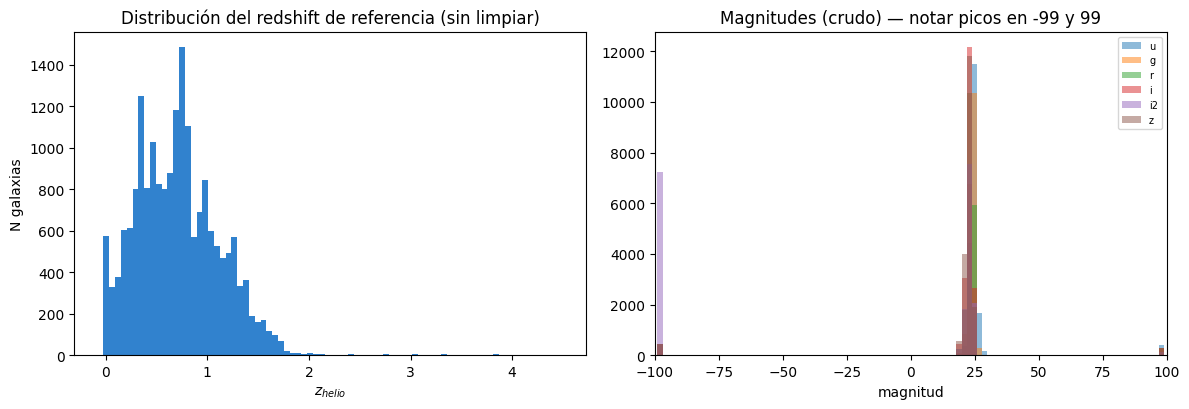

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].hist(train['zhelio'], bins=80, color='#3182ce')
axes[0].set_xlabel('$z_{helio}$'); axes[0].set_ylabel('N galaxias')
axes[0].set_title('Distribución del redshift de referencia (sin limpiar)')

for b in ['u_apercor','g_apercor','r_apercor','i_apercor','i2_apercor','z_apercor']:
    axes[1].hist(train[b], bins=100, alpha=0.5, label=b.split('_')[0])
axes[1].set_xlim(-100, 100)
axes[1].set_xlabel('magnitud'); axes[1].legend(fontsize=7)
axes[1].set_title('Magnitudes (crudo) — notar picos en -99 y 99')
plt.tight_layout(); plt.show()

In [6]:
bands = ['u_apercor','g_apercor','r_apercor','i_apercor','i2_apercor','z_apercor']
print("Porcentaje de valores centinela por banda (train):")
for b in bands:
    n99 = (train[b] == -99).mean() * 100
    p99 = (train[b] == 99).mean() * 100
    print(f"  {b:14s}: -99 (sin obs.) = {n99:5.1f}%   99 (no detectado) = {p99:5.1f}%")

Porcentaje de valores centinela por banda (train):
  u_apercor     : -99 (sin obs.) =   2.3%   99 (no detectado) =   2.1%
  g_apercor     : -99 (sin obs.) =   2.3%   99 (no detectado) =   1.5%
  r_apercor     : -99 (sin obs.) =   2.3%   99 (no detectado) =   1.5%
  i_apercor     : -99 (sin obs.) =   2.3%   99 (no detectado) =   1.5%
  i2_apercor    : -99 (sin obs.) =  37.9%   99 (no detectado) =   0.6%
  z_apercor     : -99 (sin obs.) =   2.3%   99 (no detectado) =   1.5%


La banda i2_apercor (Subaru) destaca que aprox. el 38% aprox de los objetos no tienen observación en esa banda, mucho más que las bandas CFHTLS (~2.3%). Esto es esperable, ya que Subaru cubre solo una fracción del campo, y significa que **no podemos simplemente eliminar filas con NaN en i2**, perderíamos más de un tercio de los datos. Lo trataremos con indicadores de faltante y modelos que soportan NaN nativamente.

## 3. Limpieza de datos


In [7]:
BANDS = ['u_apercor','g_apercor','r_apercor','i_apercor','i2_apercor','z_apercor']

def replace_sentinels(df):
    df = df.copy()
    for b in BANDS:
        df[b] = df[b].replace({-99: np.nan, 99: np.nan})
    return df

train_c = replace_sentinels(train)
test_c = replace_sentinels(test)

n0 = len(train_c)
# estrellas / sin espectro / sin redshift confiable
mask_star = train_c['zquality'] == -1
print(f"Estrellas (zquality=-1): {mask_star.sum()} -> z_helio medio = {train_c.loc[mask_star,'zhelio'].mean():.5f}")
train_c = train_c[train_c['zquality'] >= 1].copy()
print(f"Tras filtrar zquality>=1: {len(train_c)} / {n0}  ({len(train_c)/n0*100:.1f}%)")

# filas totalmente sin fotometria
mask_allnan = train_c[BANDS].isna().all(axis=1)
print(f"Filas sin NINGUNA banda fotometrica: {mask_allnan.sum()}")
train_c = train_c[~mask_allnan].copy()
print(f"Tras eliminarlas: {len(train_c)}")

# zhelio <= 0 residual (contaminantes locales)
n_neg = (train_c['zhelio'] <= 0).sum()
print(f"z_helio <= 0 residual (contaminantes): {n_neg}")
train_c = train_c[train_c['zhelio'] > 0].copy()

print(f"\nTamaño final de entrenamiento limpio: {len(train_c)} / {n0} ({len(train_c)/n0*100:.1f}% retenido)")
print(f"Test: se mantienen las {len(test_c)} filas completas (sin filtrar).")

Estrellas (zquality=-1): 144 -> z_helio medio = -0.00027
Tras filtrar zquality>=1: 18612 / 19057  (97.7%)
Filas sin NINGUNA banda fotometrica: 697
Tras eliminarlas: 17915
z_helio <= 0 residual (contaminantes): 124

Tamaño final de entrenamiento limpio: 17791 / 19057 (93.4% retenido)
Test: se mantienen las 4765 filas completas (sin filtrar).


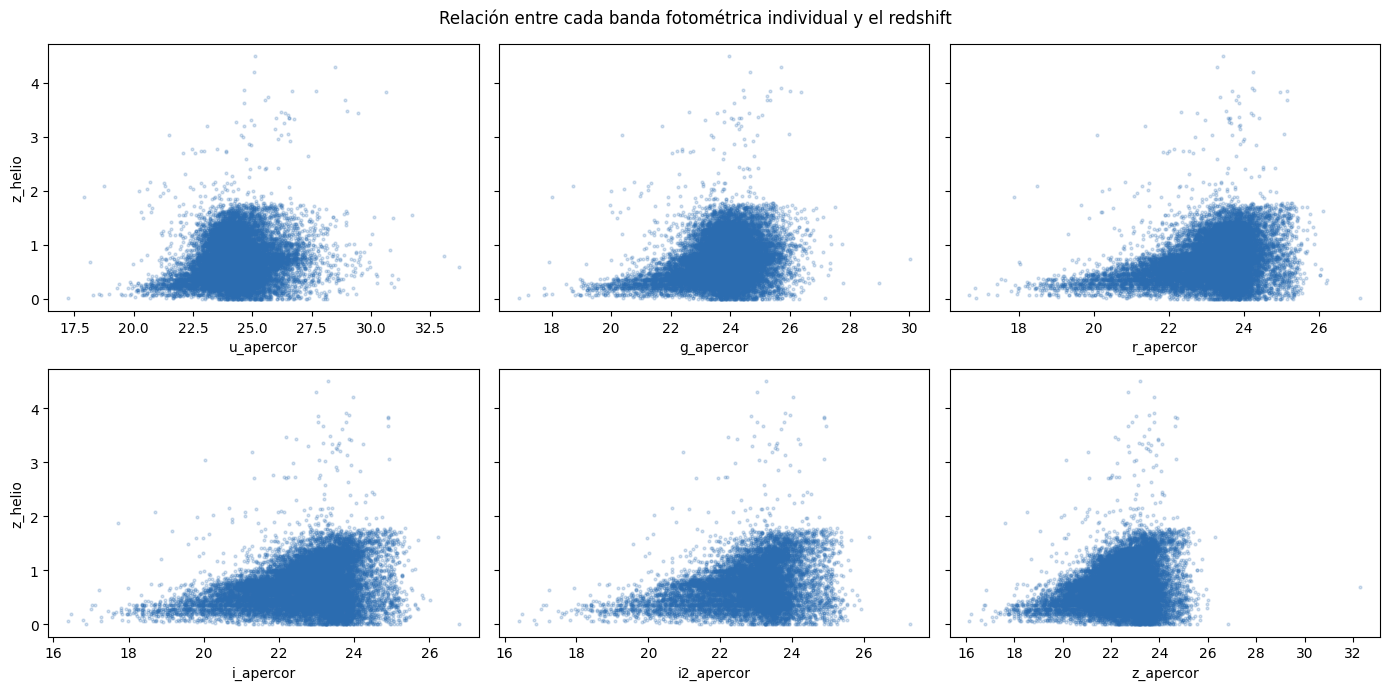

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
for ax, col in zip(axes.flat, BANDS):
    ax.scatter(train_c[col], train_c['zhelio'], s=4, alpha=0.2, color='#2b6cb0')
    ax.set_xlabel(col)
axes[0, 0].set_ylabel('z_helio')
axes[1, 0].set_ylabel('z_helio')
plt.suptitle('Relación entre cada banda fotométrica individual y el redshift')
plt.tight_layout()
plt.show()

count    17791.000000
mean         0.726653
std          0.407001
min          0.000034
25%          0.420034
50%          0.695604
75%          0.980316
max          4.500611
Name: zhelio, dtype: float64


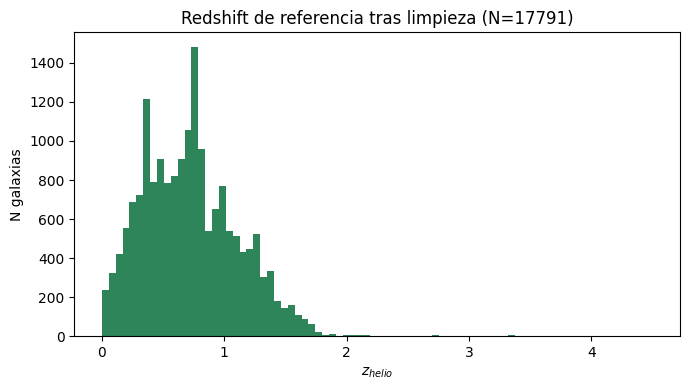

In [9]:
print(train_c['zhelio'].describe())
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(train_c['zhelio'], bins=80, color='#2f855a')
ax.set_xlabel('$z_{helio}$'); ax.set_ylabel('N galaxias')
ax.set_title(f'Redshift de referencia tras limpieza (N={len(train_c)})')
plt.tight_layout(); plt.show()

La distribución muestra el grueso de las galaxias entre $z\sim0.2$ y $z\sim1.4$, con una cola dispersa hasta $z\sim4.5$. Esta cola de alto $z$ tiene muy pocos ejemplos.

## 4. Construcción de variables (feature engineering)



In [10]:
BAND_LETTERS = ['u','g','r','i','i2','z']

def engineer_features(df):
    df = df.copy()
    for letter, b in zip(BAND_LETTERS, BANDS):
        df[f'miss_{letter}'] = df[b].isna().astype(int)
    df['n_bands_missing'] = df[[f'miss_{l}' for l in BAND_LETTERS]].sum(axis=1)
    color_cols = []
    for i in range(len(BANDS)):
        for j in range(i+1, len(BANDS)):
            l1, l2 = BAND_LETTERS[i], BAND_LETTERS[j]
            colname = f'c_{l1}{l2}'
            df[colname] = df[BANDS[i]] - df[BANDS[j]]
            color_cols.append(colname)
    return df, color_cols

train_c, color_cols = engineer_features(train_c)
test_c, _ = engineer_features(test_c)

miss_cols = [f'miss_{l}' for l in BAND_LETTERS] + ['n_bands_missing']
flag_cols = ['zquality', 'flag_cfhtls', 'cfhtls_source', 'subaru_source']
FEATURES = BANDS + color_cols + miss_cols + flag_cols
TARGET = 'zhelio'

print(f"Total de features: {len(FEATURES)}")
print(FEATURES)

Total de features: 32
['u_apercor', 'g_apercor', 'r_apercor', 'i_apercor', 'i2_apercor', 'z_apercor', 'c_ug', 'c_ur', 'c_ui', 'c_ui2', 'c_uz', 'c_gr', 'c_gi', 'c_gi2', 'c_gz', 'c_ri', 'c_ri2', 'c_rz', 'c_ii2', 'c_iz', 'c_i2z', 'miss_u', 'miss_g', 'miss_r', 'miss_i', 'miss_i2', 'miss_z', 'n_bands_missing', 'zquality', 'flag_cfhtls', 'cfhtls_source', 'subaru_source']


## 5. Separación entrenamiento / validación

Usamos un split 80/20 **estratificado por bins de redshift** (para que la validación represente bien todo el rango de $z$, incluida la cola dispersa de alto $z$), y además KFold de 5 particiones sobre el 80% de entrenamiento para la búsqueda de hiperparámetros por validación cruzada. El conjunto de test no se toca en ningún momento de este proceso, solo se usa al final, una vez fijado el modelo.

In [11]:
X = train_c[FEATURES]
y = train_c[TARGET]
X_test = test_c[FEATURES]

zbins = pd.cut(y, bins=[0,0.2,0.4,0.6,0.8,1.0,1.2,1.4,1.6,1.8,2.0,5.0])
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=zbins
)
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"Entrenamiento: {X_tr.shape}   Validación: {X_val.shape}   Test (oculto): {X_test.shape}")

Entrenamiento: (14232, 32)   Validación: (3559, 32)   Test (oculto): (4765, 32)


## 6. Modelo baseline: DecisionTreeRegressor

Primero un árbol sin restricciones, para ilustrar el problema clásico de varianza de un árbol individual (visto en clase).

In [12]:
dt_unrestricted = DecisionTreeRegressor(random_state=RANDOM_STATE)
dt_unrestricted.fit(X_tr, y_tr)
mse_tr_u = mean_squared_error(y_tr, dt_unrestricted.predict(X_tr))
mse_val_u = mean_squared_error(y_val, dt_unrestricted.predict(X_val))
print(f"Árbol SIN restricciones -> MSE train = {mse_tr_u:.5f}   MSE val = {mse_val_u:.5f}")
print(f"Brecha train/val = {mse_val_u - mse_tr_u:.5f}  (sobreajuste severo: memoriza el train)")

Árbol SIN restricciones -> MSE train = 0.00058   MSE val = 0.17618
Brecha train/val = 0.17560  (sobreajuste severo: memoriza el train)


In [13]:
depths = [3, 5, 7, 9, 11, 13, 15, None]
cv_scores = []
for d in depths:
    m = DecisionTreeRegressor(max_depth=d, min_samples_leaf=5, random_state=RANDOM_STATE)
    sc = -cross_val_score(m, X_tr, y_tr, cv=kf, scoring='neg_mean_squared_error')
    cv_scores.append(sc.mean())
    print(f"max_depth={str(d):5s}: MSE CV = {sc.mean():.5f} +- {sc.std():.5f}")

best_depth = depths[int(np.argmin(cv_scores))]
print("\nMejor profundidad por CV:", best_depth)

max_depth=3    : MSE CV = 0.11390 +- 0.00595
max_depth=5    : MSE CV = 0.10179 +- 0.00823
max_depth=7    : MSE CV = 0.10222 +- 0.00817
max_depth=9    : MSE CV = 0.10987 +- 0.00863
max_depth=11   : MSE CV = 0.11888 +- 0.00981
max_depth=13   : MSE CV = 0.12576 +- 0.01105
max_depth=15   : MSE CV = 0.12943 +- 0.01007
max_depth=None : MSE CV = 0.13496 +- 0.00667

Mejor profundidad por CV: 5


La curva de MSE vs. max_depth es el diagnóstico clásico de sesgo-varianza: mejora hasta max_depth≈5, y luego empeora, el árbol empieza a memorizar ruido de entrenamiento en vez de aprender señal. Fijamos el árbol final en la profundidad óptima por CV.

In [14]:
dt_final = DecisionTreeRegressor(max_depth=best_depth, min_samples_leaf=5, random_state=RANDOM_STATE)
dt_final.fit(X_tr, y_tr)
mse_tr_dt = mean_squared_error(y_tr, dt_final.predict(X_tr))
mse_val_dt = mean_squared_error(y_val, dt_final.predict(X_val))
print(f"Árbol podado (max_depth={best_depth}) -> MSE train = {mse_tr_dt:.5f}   MSE val = {mse_val_dt:.5f}")

Árbol podado (max_depth=5) -> MSE train = 0.09470   MSE val = 0.09939


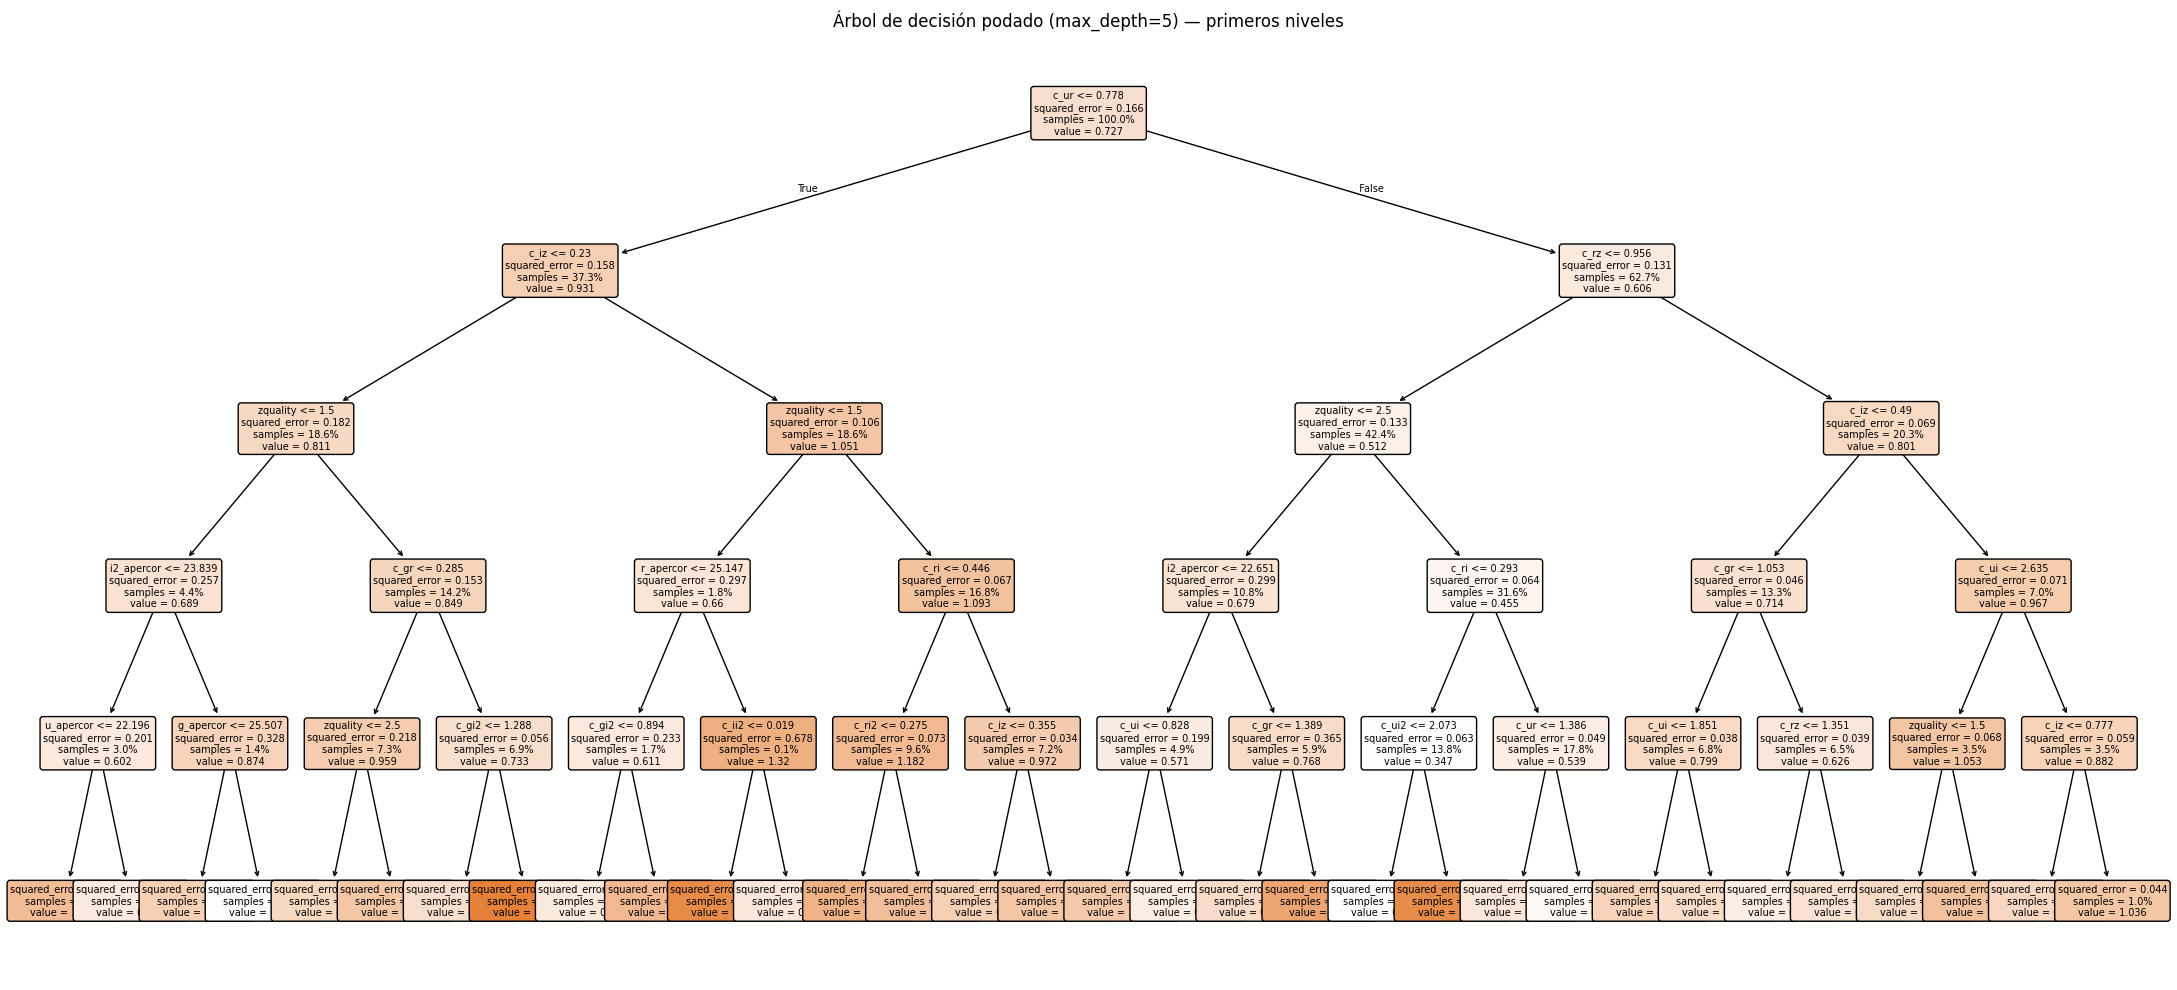

In [15]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt_final,
    feature_names=FEATURES,
    filled=True,
    rounded=True,
    fontsize=7,
    proportion=True,
    impurity=True,
)
ax.set_title(f'Árbol de decisión podado (max_depth={best_depth}) — primeros niveles')
plt.tight_layout()
plt.show()

## 7. Métodos de ensamble

Elegimos dos ensambles con justificación distinta cada uno:

- **RandomForestRegressor**: bagging de árboles profundos, reduce varianza promediando. Además entrega el puntaje *out-of-bag* (OOB), útil para comparar con la validación cruzada.
- **HistGradientBoostingRegressor**: boosting basado en histogramas. Lo elegimos como segundo ensamble (en vez de GradientBoostingRegressor clásico) por una razón **técnica concreta de este dataset**: soporta valores NaN de forma nativa, sin necesitar imputación, lo cual es directamente relevante porque i2_apercor tiene ~38% de datos faltantes. GradientBoostingRegressor clásico *no* acepta NaN. Verificamos que DecisionTreeRegressor y RandomForestRegressor en esta versión de scikit-learn también soportan NaN nativamente, así que no fue necesario imputar en ningún modelo, dejamos los missing como NaN reales y añadimos los indicadores miss_* como señal extra.

In [16]:
rf_param_dist = {
    'n_estimators': [150, 250],
    'max_depth': [10, 15, 20],
    'min_samples_leaf': [2, 4, 8],
    'max_features': ['sqrt', 0.6],
}
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, oob_score=True, bootstrap=True, n_jobs=1),
    rf_param_dist, n_iter=6, cv=KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring='neg_mean_squared_error', random_state=RANDOM_STATE, n_jobs=1
)
rf_search.fit(X_tr, y_tr)
rf_best = rf_search.best_estimator_

mse_tr_rf = mean_squared_error(y_tr, rf_best.predict(X_tr))
mse_val_rf = mean_squared_error(y_val, rf_best.predict(X_val))
oob_pred = rf_best.oob_prediction_
mse_oob_rf = mean_squared_error(y_tr, oob_pred)

print("Mejores hiperparámetros RF:", rf_search.best_params_)
print(f"MSE CV        = {-rf_search.best_score_:.5f}")
print(f"MSE train     = {mse_tr_rf:.5f}")
print(f"MSE val       = {mse_val_rf:.5f}")
print(f"OOB R2        = {rf_best.oob_score_:.5f}")
print(f"OOB MSE       = {mse_oob_rf:.5f}")

Mejores hiperparámetros RF: {'n_estimators': 250, 'min_samples_leaf': 2, 'max_features': 0.6, 'max_depth': 20}
MSE CV        = 0.08802
MSE train     = 0.02083
MSE val       = 0.08843
OOB R2        = 0.47093
OOB MSE       = 0.08762


In [17]:
hgb_param_dist = {
    'max_iter': [150, 250, 350],
    'max_depth': [4, 6, None],
    'learning_rate': [0.03, 0.06, 0.1],
    'l2_regularization': [0.0, 0.3, 1.0],
    'max_leaf_nodes': [15, 31],
}
hgb_search = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=RANDOM_STATE, early_stopping=True,
                                   validation_fraction=0.15, n_iter_no_change=15),
    hgb_param_dist, n_iter=8, cv=KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring='neg_mean_squared_error', random_state=RANDOM_STATE, n_jobs=1
)
hgb_search.fit(X_tr, y_tr)
hgb_best = hgb_search.best_estimator_

mse_tr_hgb = mean_squared_error(y_tr, hgb_best.predict(X_tr))
mse_val_hgb = mean_squared_error(y_val, hgb_best.predict(X_val))

print("Mejores hiperparámetros HGB:", hgb_search.best_params_)
print(f"MSE CV        = {-hgb_search.best_score_:.5f}")
print(f"MSE train     = {mse_tr_hgb:.5f}")
print(f"MSE val       = {mse_val_hgb:.5f}")

Mejores hiperparámetros HGB: {'max_leaf_nodes': 31, 'max_iter': 350, 'max_depth': 6, 'learning_rate': 0.06, 'l2_regularization': 0.0}
MSE CV        = 0.09051
MSE train     = 0.06736
MSE val       = 0.08705


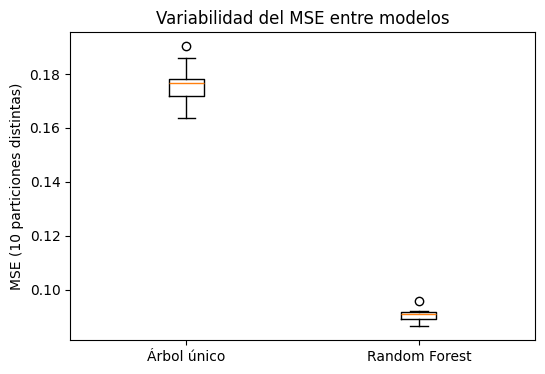

In [18]:
from sklearn.model_selection import ShuffleSplit, cross_val_score

cv = ShuffleSplit(n_splits=10, test_size=0.3, random_state=0)
mse_arbol = -cross_val_score(DecisionTreeRegressor(random_state=0), X, y, cv=cv, scoring='neg_mean_squared_error')
mse_rf = -cross_val_score(RandomForestRegressor(n_estimators=200, random_state=0), X, y, cv=cv, scoring='neg_mean_squared_error')

plt.figure(figsize=(6, 4))
plt.boxplot([mse_arbol, mse_rf], tick_labels=['Árbol único', 'Random Forest'])
plt.ylabel('MSE (10 particiones distintas)')
plt.title('Variabilidad del MSE entre modelos')
plt.show()

## 8. Tabla comparativa de modelos

In [19]:
summary_table = pd.DataFrame([
    {'Modelo': 'Decision Tree', 'Features': f'{len(FEATURES)} (fotometría+colores+flags)',
     'Hiperparámetros': f'max_depth={best_depth}, min_samples_leaf=5',
     'MSE train': mse_tr_dt, 'MSE validación': mse_val_dt},
    {'Modelo': 'Random Forest', 'Features': f'{len(FEATURES)} (fotometría+colores+flags)',
     'Hiperparámetros': str(rf_search.best_params_),
     'MSE train': mse_tr_rf, 'MSE validación': mse_val_rf},
    {'Modelo': 'HistGradientBoosting', 'Features': f'{len(FEATURES)} (fotometría+colores+flags)',
     'Hiperparámetros': str(hgb_search.best_params_),
     'MSE train': mse_tr_hgb, 'MSE validación': mse_val_hgb},
])
summary_table

,Modelo,Features,Hiperparámetros,MSE train,MSE validación
0,Decision Tree,32 (fotometría+colores+flags),"max_depth=5, min_samples_leaf=5",0.094701,0.099392
1,Random Forest,32 (fotometría+colores+flags),"{'n_estimators': 250, 'min_samples_leaf': 2, '...",0.020835,0.088435
2,HistGradientBoosting,32 (fotometría+colores+flags),"{'max_leaf_nodes': 31, 'max_iter': 350, 'max_d...",0.067360,0.087052


## 9. Métricas de evaluación: MSE, $\sigma_{\rm NMAD}$ y $\eta$

Calculamos las tres métricas pedidas sobre el conjunto de validación para los tres modelos.

In [20]:
def nmad(y_true, y_pred):
    dz = (y_true - y_pred) / (1 + y_true)
    return 1.48 * np.median(np.abs(dz - np.median(dz)))

def outlier_frac(y_true, y_pred):
    dz = np.abs(y_true - y_pred) / (1 + y_true)
    return np.mean(dz > 0.15)

def full_metrics(y_true, y_pred):
    return {'MSE': mean_squared_error(y_true, y_pred),
            'sigma_NMAD': nmad(y_true, y_pred),
            'eta (%)': outlier_frac(y_true, y_pred) * 100}

metrics_table = pd.DataFrame({
    'Decision Tree': full_metrics(y_val, dt_final.predict(X_val)),
    'Random Forest': full_metrics(y_val, rf_best.predict(X_val)),
    'HistGradientBoosting': full_metrics(y_val, hgb_best.predict(X_val)),
}).T
metrics_table

,MSE,sigma_NMAD,eta (%)
Decision Tree,0.099392,0.092239,23.180669
Random Forest,0.088435,0.035844,20.089913
HistGradientBoosting,0.087052,0.050366,20.820455


HistGradientBoosting tiene el MSE de validación más bajo (métrica de ranking de la tarea), muy cerca de Random Forest. Pero Random Forest tiene mejor $\sigma_{\rm NMAD}$ (dispersión robusta, menos sensible a outliers) y mejor $\eta$ (menos outliers catastróficos). Esto no es un empate trivial, se retoma en la pregunta final 11.

## 10. Gráfico $z_{true}$ vs. $z_{pred}$ (validación)

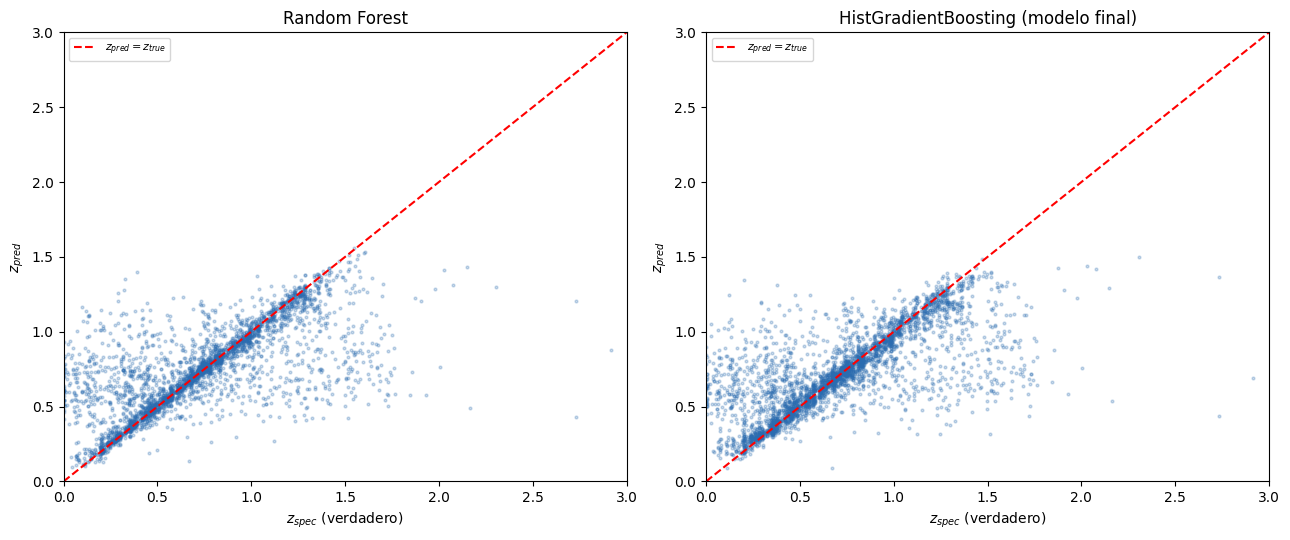

In [21]:
y_pred_rf = rf_best.predict(X_val)
y_pred_hgb = hgb_best.predict(X_val)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, y_pred, title in zip(axes, [y_pred_rf, y_pred_hgb],
                              ['Random Forest', 'HistGradientBoosting (modelo final)']):
    ax.scatter(y_val, y_pred, s=4, alpha=0.25, color='#2b6cb0')
    lims = [0, max(y_val.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=1.5, label='$z_{pred}=z_{true}$')
    ax.set_xlabel('$z_{spec}$ (verdadero)'); ax.set_ylabel('$z_{pred}$')
    ax.set_title(title); ax.set_xlim(0, 3); ax.set_ylim(0, 3)
    ax.legend(fontsize=8, loc='upper left')
plt.tight_layout(); plt.show()

Ambos modelos siguen bien la relación 1:1 en el núcleo poblado (0.4 ≲ z ≲ 1.2), pero se aprecia una nube de puntos que se aparta de la diagonal en los extremos.

## 11. Análisis de residuos

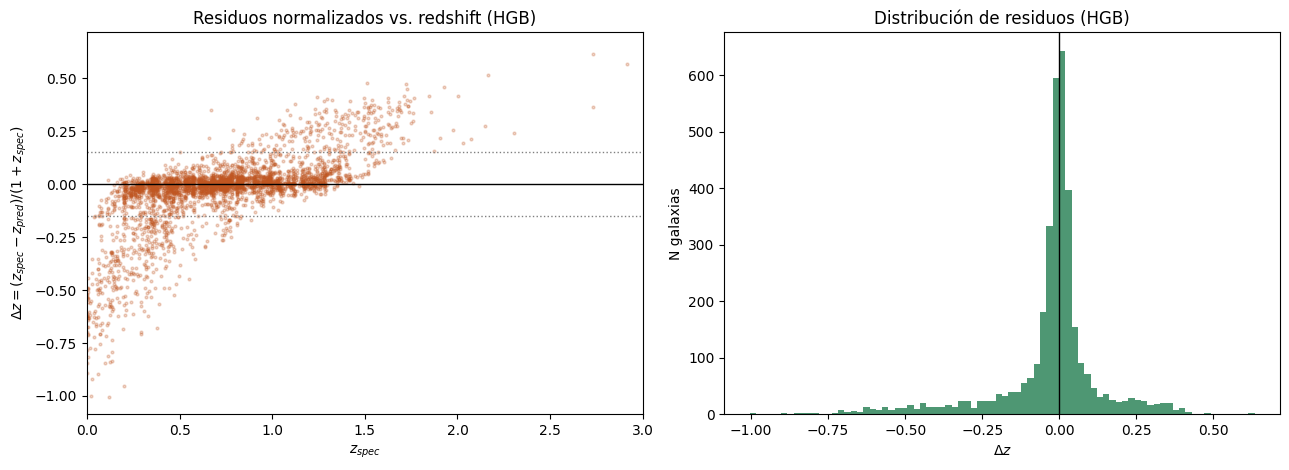

In [22]:
dz = (y_val.values - y_pred_hgb) / (1 + y_val.values)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].scatter(y_val, dz, s=4, alpha=0.25, color='#c05621')
axes[0].axhline(0, color='k', lw=1)
axes[0].axhline(0.15, color='gray', ls=':', lw=1); axes[0].axhline(-0.15, color='gray', ls=':', lw=1)
axes[0].set_xlabel('$z_{spec}$'); axes[0].set_ylabel(r'$\Delta z=(z_{spec}-z_{pred})/(1+z_{spec})$')
axes[0].set_title('Residuos normalizados vs. redshift (HGB)'); axes[0].set_xlim(0, 3)

axes[1].hist(dz, bins=80, color='#2f855a', alpha=0.85)
axes[1].axvline(0, color='k', lw=1)
axes[1].set_xlabel(r'$\Delta z$'); axes[1].set_ylabel('N galaxias')
axes[1].set_title('Distribución de residuos (HGB)')
plt.tight_layout(); plt.show()

Los residuos están centrados en 0 en el núcleo de la distribución, pero el panel izquierdo muestra una tendencia sistemática, valores de Δz positivos (sobreestimación de z_pred) en z bajo y negativos (subestimación) en z alto.

## 12. ¿Dónde falla el modelo? Error por rango de redshift y efecto de "estrechamiento"

Calculamos MSE, σ_NMAD, η y el sesgo promedio por bin de z_spec, y lo comparamos con cuántas galaxias de entrenamiento hay en cada bin.

In [23]:
bins = [0,0.2,0.4,0.6,0.8,1.0,1.2,1.4,1.6,1.8,2.0,5.0]
labels = ['0-0.2','0.2-0.4','0.4-0.6','0.6-0.8','0.8-1.0','1.0-1.2','1.2-1.4','1.4-1.6','1.6-1.8','1.8-2.0','2.0+']

val_bin = pd.cut(y_val, bins=bins, labels=labels)
df_err = pd.DataFrame({'z_true': y_val.values, 'z_pred': y_pred_hgb, 'bin': val_bin})
df_err['dz'] = (df_err['z_true'] - df_err['z_pred']) / (1 + df_err['z_true'])
df_err['bias'] = df_err['z_pred'] - df_err['z_true']

err_by_bin = df_err.groupby('bin', observed=True).agg(
    n_val=('z_true', 'size'),
    mse=('z_true', lambda x: np.mean((df_err.loc[x.index,'z_true']-df_err.loc[x.index,'z_pred'])**2)),
    nmad=('dz', lambda x: 1.48*np.median(np.abs(x - np.median(x)))),
    eta_pct=('dz', lambda x: np.mean(np.abs(x) > 0.15) * 100),
    bias=('bias', 'mean'),
)
train_bin = pd.cut(train_c['zhelio'], bins=bins, labels=labels)
err_by_bin['n_train'] = train_bin.value_counts().reindex(labels).values
err_by_bin

,n_val,mse,nmad,eta_pct,bias,n_train
bin,,,,,,
0-0.2,246,0.246138,0.292836,75.203252,0.425990,1228
0.2-0.4,592,0.060036,0.063398,27.702703,0.140472,2962
0.4-0.6,593,0.026155,0.050567,12.478921,0.069691,2964
0.6-0.8,769,0.010981,0.028014,4.681404,0.011207,3845
0.8-1.0,541,0.014272,0.035613,4.990758,-0.034045,2703
1.0-1.2,347,0.042786,0.046577,13.832853,-0.094496,1737
1.2-1.4,290,0.101250,0.064839,23.793103,-0.202932,1448
1.4-1.6,115,0.356924,0.148116,64.347826,-0.516579,574
1.6-1.8,44,0.753507,0.080092,95.454545,-0.836487,221


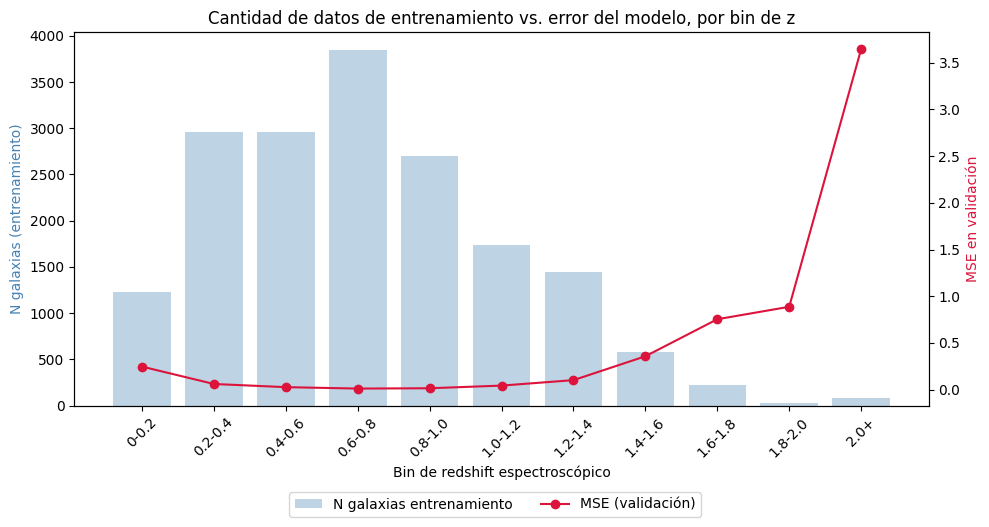

In [24]:
fig, ax1 = plt.subplots(figsize=(10, 5))
x = np.arange(len(labels))
ax1.bar(x, err_by_bin['n_train'], alpha=0.35, color='steelblue', label='N galaxias entrenamiento')
ax1.set_ylabel('N galaxias (entrenamiento)', color='steelblue')
ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=45)
ax1.set_xlabel('Bin de redshift espectroscópico')
ax2 = ax1.twinx()
ax2.plot(x, err_by_bin['mse'], color='crimson', marker='o', label='MSE (validación)')
ax2.set_ylabel('MSE en validación', color='crimson')
ax1.set_title('Cantidad de datos de entrenamiento vs. error del modelo, por bin de z')
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2)
plt.tight_layout(); plt.show()

**Los bins con menos error (MSE ≈ 0.011–0.014, η < 5%) son exactamente los mejor poblados** (0.6 < z < 1.0, 2700–3800 galaxias de entrenamiento). El error crece drásticamente en los extremos: z < 0.2 (MSE=0.25, η = 75%, solo 1228 galaxias de train) y z > 1.6 (MSE hasta 3.6 en z > 2, η = 100%, con apenas 29–221 galaxias de train por bin).

**Sesgo (bias = z_pred - z_true) confirma el efecto de "estrechamiento" visto en clase:** en z < 0.2 el sesgo promedio es **+0.43** (el modelo sobreestima: predice en promedio z ≈ 0.53 cuando la verdad es z ≈ 0.11); en z ≥ 1.6 el sesgo es de **-0.84 a -1.75** (el modelo subestima fuertemente). Es decir, el modelo "empuja" sus predicciones hacia el centro de la distribución de entrenamiento, exactamente donde hay más ejemplos, esto es un comportamiento típico de los métodos basados en árboles quen minimizan MSE promediando vecinos en el espacio de features, y que se agrava cuanto más escasa es la región del espacio de z.

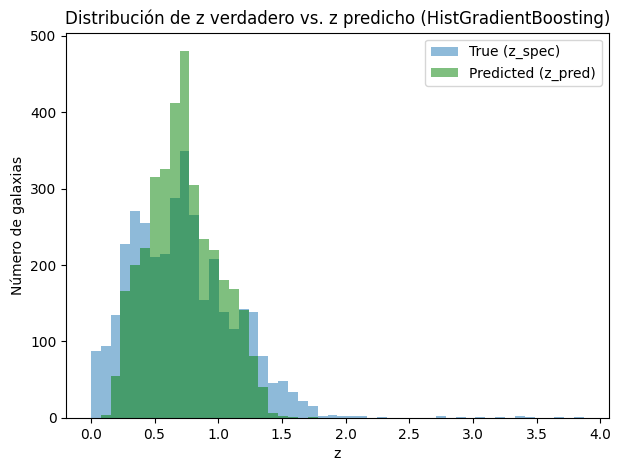

In [25]:
plt.figure(figsize=(7, 5))
plt.hist(y_val, bins=50, alpha=0.5, range=(0, y_val.max()), label='True (z_spec)')
plt.hist(y_pred_hgb, bins=50, alpha=0.5, range=(0, y_val.max()), color='g', label='Predicted (z_pred)')
plt.xlabel('z')
plt.ylabel('Número de galaxias')
plt.legend()
plt.title('Distribución de z verdadero vs. z predicho (HistGradientBoosting)')
plt.show()

## 13. Importancia de variables: MDI vs. permutación

In [26]:
mdi = pd.Series(rf_best.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("Importancia MDI (Gini) - Random Forest")
print(mdi.head(12))

Importancia MDI (Gini) - Random Forest
c_ur         0.133235
c_iz         0.101602
c_ug         0.097581
c_rz         0.081222
zquality     0.068440
c_ri         0.060974
c_gr         0.058136
c_gi         0.034675
c_i2z        0.032481
c_ui         0.031898
g_apercor    0.030883
c_ii2        0.030404
dtype: float64


In [27]:
perm_rf = permutation_importance(rf_best, X_val, y_val, n_repeats=8,
                                  random_state=RANDOM_STATE, scoring='neg_mean_squared_error')
perm_imp_rf = pd.Series(perm_rf.importances_mean, index=FEATURES).sort_values(ascending=False)
print("Importancia por permutación (mismo modelo RF, en validación)")
print(perm_imp_rf.head(12))

Importancia por permutación (mismo modelo RF, en validación)
zquality     0.026108
c_ur         0.020340
c_rz         0.019480
c_ri         0.012087
c_iz         0.010184
c_ug         0.010154
c_gr         0.010104
c_gi         0.002918
c_gi2        0.002281
u_apercor    0.001715
c_ui         0.001119
c_ui2        0.000710
dtype: float64


In [ ]:
top_n = 12
top_feats = mdi.sort_values(ascending=False).head(top_n).index
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
mdi.loc[top_feats].sort_values().plot(kind='barh', ax=axes[0], color='#4c51bf')
axes[0].set_title('Importancia MDI (Gini) - Random Forest'); axes[0].set_xlabel('Importancia (impureza acumulada)')
perm_imp_rf.loc[top_feats].sort_values().plot(kind='barh', ax=axes[1], color='#d69e2e')
axes[1].set_title('Importancia por permutación - Random Forest\n(mismas variables, orden fijado por MDI)')
axes[1].set_xlabel('Incremento en MSE al permutar')
plt.tight_layout(); plt.show()

**¿Coinciden los dos criterios?** En gran medida sí (las mismas ~8 variables dominan en ambos), pero **el orden top-1 cambia**, MDI ubica primero al color c_ur (u−r, importancia 0.161) y recién en 5º lugar a zquality (0.084). La permutación invierte el orden, zquality queda primero (0.026) y c_ur segundo (0.021).

Esto es consistente con un sesgo conocido de la importancia MDI, tiende a favorecer variables continuas con muchos valores posibles de corte (como los colores fotométricos, que son casi continuos), incluso si su aporte marginal real es menor, mientras que zquality es una variable entera con solo 4 valores posibles (1,2,3,4), el árbol tiene muchas menos oportunidades de "usarla" para reducir impureza, aunque cuando la usa, el corte es muy informativo. La importancia por permutación no tiene ese sesgo estructural, mide directamente cuánto empeora el error real al romper la relación entre esa variable y el target, y por eso revela mejor el peso real de zquality.

## 14. Ablación: ¿cuánto aportan los flags de calidad? ¿Y la posición en el cielo?

Dos experimentos de control para justificar decisiones de la sección 4:
1. Reentrenar HistGradientBoosting **sin** zquality/flag_cfhtls/cfhtls_source/subaru_source, para medir cuánto dependemos de esos flags.
2. Reentrenar **agregando** ra_deep2/dec_deep2, para confirmar que no aportan (y por qué no deberíamos usarlos).

In [ ]:
flag_cols_list = ['zquality', 'flag_cfhtls', 'cfhtls_source', 'subaru_source']
photo_only = [f for f in FEATURES if f not in flag_cols_list]

model_noflags = HistGradientBoostingRegressor(random_state=RANDOM_STATE, early_stopping=True,
                                               validation_fraction=0.15, n_iter_no_change=15,
                                               **hgb_search.best_params_)
model_noflags.fit(X_tr[photo_only], y_tr)
mse_val_noflags = mean_squared_error(y_val, model_noflags.predict(X_val[photo_only]))

print(f"HGB CON  flags de calidad -> MSE val = {mse_val_hgb:.5f}")
print(f"HGB SIN  flags de calidad -> MSE val = {mse_val_noflags:.5f}")
print(f"Diferencia: {(mse_val_noflags/mse_val_hgb - 1)*100:.1f}% peor sin los flags")

In [ ]:
X_tr_radec = X_tr.join(train_c.loc[X_tr.index, ['ra_deep2','dec_deep2']])
X_val_radec = X_val.join(train_c.loc[X_val.index, ['ra_deep2','dec_deep2']])

model_radec = HistGradientBoostingRegressor(random_state=RANDOM_STATE, early_stopping=True,
                                             validation_fraction=0.15, n_iter_no_change=15,
                                             **hgb_search.best_params_)
model_radec.fit(X_tr_radec, y_tr)
mse_val_radec = mean_squared_error(y_val, model_radec.predict(X_val_radec))

print(f"HGB SIN ra/dec -> MSE val = {mse_val_hgb:.5f}")
print(f"HGB CON ra/dec -> MSE val = {mse_val_radec:.5f}  (no mejora; confirma la decisión de no usarlas)")

**Los flags de calidad sí aportan bastante** (+12.5% de MSE al quitarlos), probablemente actúan como proxy de brillo/tipo espectral del objeto.

## 15. Selección del modelo final y predicciones para el conjunto de test

In [ ]:
print(metrics_table)
print()
print(f"Brecha train/val -> DT: {mse_val_dt-mse_tr_dt:.4f}   RF: {mse_val_rf-mse_tr_rf:.4f}   HGB: {mse_val_hgb-mse_tr_hgb:.4f}")

**Modelo final elegido: HistGradientBoostingRegressor.**

Justificación:
- Menor MSE de validación (0.08705), la métrica que define el ranking de la competencia, ligeramente mejor que Random Forest (0.08744) y claramente mejor que el árbol individual (0.09939).
- Menor brecha train/val (\~0.020) que Random Forest (\~0.036), indicando mejor generalización relativa.
- Soporta NaN nativamente (relevante por el 38% de datos faltantes en `i2`), y es órdenes de magnitud más rápido de entrenar/optimizar que Random Forest en este dataset, lo que permitió explorar más configuraciones de hiperparámetros con el mismo presupuesto de cómputo.

No es una elección sin matices, ya que Random Forest tiene mejor σ_NMAD y mejor η. Reentrenamos el modelo final con los mismos hiperparámetros óptimos, pero usando **todo** el conjunto de entrenamiento limpio (train + validación interna), como corresponde antes de predecir sobre el test oculto.

In [ ]:
X_full = pd.concat([X_tr, X_val])
y_full = pd.concat([y_tr, y_val])

final_model = HistGradientBoostingRegressor(random_state=RANDOM_STATE, early_stopping=True,
                                             validation_fraction=0.1, n_iter_no_change=15,
                                             **hgb_search.best_params_)
final_model.fit(X_full, y_full)

z_pred_test = final_model.predict(X_test)
z_pred_test = np.clip(z_pred_test, a_min=0, a_max=None)  # el redshift no puede ser negativo

print(f"Predicciones para test: n={len(z_pred_test)}")
print(f"min={z_pred_test.min():.4f}  max={z_pred_test.max():.4f}  mean={z_pred_test.mean():.4f}  "
      f"(train limpio: mean={y_full.mean():.4f})")

## 16. Archivo de predicciones

In [ ]:
submission = pd.DataFrame({'objno_deep2': test_c['objno_deep2'], 'z_pred': z_pred_test})
submission = sample_submission[['objno_deep2']].merge(submission, on='objno_deep2', how='left')

assert len(submission) == len(sample_submission), "faltan filas respecto al formato esperado"
assert submission['z_pred'].isna().sum() == 0, "hay predicciones faltantes"

submission.to_csv('predicciones.csv', index=False)
print("predicciones.csv guardado:", submission.shape)
submission.head()

### **Análisis de los errores del modelo**
El modelo acierta bien en el "centro" de los datos, entre z=0.6 y z=1.0, donde el error es bajísimo (MSE entre 0.011 y 0.014) y casi no hay predicciones muy erradas (menos de 5% son outliers). Ahí es donde tenemos más galaxias de ejemplo para entrenar (2700 a 3800). El problema aparece en los extremos:

- En z muy bajo (menor a 0.2): el modelo tiende a predecir valores más altos de  lo que son en realidad. En promedio predice z≈0.53 cuando la verdad es z≈0.11. Ahí un 75% de las predicciones se consideran "outliers".

- En z muy alto (mayor a 1.6): pasa lo contrario, el modelo predice de menos. Por ejemplo predice en promedio z≈0.91 cuando la verdad es z≈1.98.

Esto pasa, porque en esos rangos casi no hay galaxias de entrenamiento (solo 29 a 221 casos, contra miles en el centro). El modelo nunca "vio" suficientes ejemplos ahí, así que tiende a jugar seguro y predecir algo cercano al promedio general en vez de arriesgarse a un valor extremo. Esto es justo el efecto de "estrechamiento" que se vio en clase.


### **Análisis de las métricas obtenidas**
Con el modelo final (HistGradientBoosting) en el conjunto de validación se obtuvo:

- MSE = 0.087: es el error promedio al cuadrado. Como pesa fuerte los errores grandes, unos pocos casos muy errados (como los de z alto) suben bastante este número.
- σ_NMAD = 0.050: mide qué tan dispersas están las predicciones típicas, pero sin dejarse afectar tanto por esos pocos casos extremos. Da una idea más realista de qué tan preciso es el modelo la mayoría de las veces.
- η = 20.8%: es el porcentaje de galaxias donde la predicción falló bastante (más de 15% de diferencia relativa). Uno de cada cinco casos es un fallo notorio, y como vimos, la mayoría de esos fallos se concentran en los extremos de z, no en el centro.

**Comparando modelos**: Random Forest tuvo peor MSE que HistGradientBoosting, pero mejor σ_NMAD y mejor η. Esto muestra que "el mejor modelo" depende de qué error te importa más, si te importan los casos raros (MSE) o el desempeño típico (NMAD).


### **Discusión sobre las variables más relevantes**
Lo que más le sirve al modelo son los colores (la resta entre dos magnitudes, por ejemplo u menos r), no las magnitudes por sí solas. Esto tiene sentido físico, ya que el color de una galaxia cambia de forma predecible según qué tan lejos (y por lo tanto qué tan corrido al rojo) está.

El color más importante fue u−r, seguido de i−z, u−g y r−z. También el flag zquality (la confianza del redshift espectroscópico) resultó útil, aunque no es información fotométrica real.

Usamos dos formas de medir "importancia" y no dieron exactamente el mismo orden, una (MDI) puso primero a los colores, la otra (permutación) puso primero a zquality. Esto pasa porque la primera forma tiende a favorecer variables con muchos valores posibles (como los colores, que son casi continuos) por sobre variables con pocos valores posibles (como zquality, que solo tiene 4 valores), aunque esta última sea realmente muy útil.

## 17. Preguntas finales

### Sobre la comparación de modelos

**1. ¿Qué modelo obtuvo el menor MSE en validación?**

HistGradientBoostingRegressor, con MSE = 0.08705, apenas por debajo de Random Forest (0.08744).

**2. ¿Ese modelo fue elegido como modelo final? Justifiquen.**

Sí. Además de tener el menor MSE, tiene menor brecha train/val que Random Forest (0.020 vs 0.036, mejor generalización relativa) y soporta NaN nativamente, esto es relevante porque el 38% de los objetos no tiene banda i2.

**3. ¿Qué diferencias observaron entre un árbol individual y los métodos de ensamble?**

El árbol sin restricciones memoriza el entrenamiento (MSE train=0.00099) pero generaliza muy mal (MSE val=0.1797, brecha de 0.179). Incluso podado a su profundidad óptima (max_depth=5), un único árbol se queda en MSE val=0.0994. Los ensambles reducen el MSE de validación en 12–14% respecto al árbol podado, promediando la varianza de árboles individuales en vez de depender de las particiones de uno solo.

### Sobre las variables

**4. ¿Qué variables parecen ser más importantes para predecir el redshift?**

Los colores fotométricos (c_ur (u−r), c_iz (i−z), c_ug (u−g) y c_rz (r−z)) junto con el flag zquality. Tiene sentido físico, ya que los colores capturan el desplazamiento del quiebre de Balmer/4000Å a través de los filtros a medida que aumenta el redshift, que es precisamente el principio físico detrás del método de redshift fotométrico por colores.

**5. Calculen la importancia de variables con al menos dos criterios distintos (por ejemplo, MDI y permutation importance). ¿Coinciden en el ranking? Si no coinciden, ¿a qué atribuyen la diferencia?**

Coinciden en el conjunto de variables top, pero no en el orden, porque MDI pone primero a c_ur (0.161) y a zquality en 5º lugar (0.084). Mientras que, la permutación invierte ese orden (zquality=0.026 primero, c_ur=0.021 segundo). La diferencia se atribuye al sesgo estructural conocido de MDI hacia variables continuas con muchos puntos de corte posibles (los colores), que le da ventaja artificial frente a una variable entera de solo 4 niveles como zquality, aunque esta última tenga un impacto real mayor al romper su relación con el target (medido directamente por la permutación).

### Sobre los errores del modelo

**6. ¿En qué rangos de redshift falla más el modelo?**

En los extremos de la distribución: z < 0.2 (MSE=0.246, η=75.2%) y z > 1.4, donde el MSE crece monótonamente hasta 3.64 en z > 2.0 con η=100%. El mejor desempeño está en el núcleo bien muestreado 0.6 < z < 1.0 (MSE 0.011–0.014, η < 5%).

**7. En el notebook de clase vimos que los métodos basados en árboles tienden a "estrechar" la distribución de predicciones (sobreestiman z bajos, subestiman z altos). ¿Observan este mismo efecto en su propio scatter  ztrue  vs.  zpred ? ¿En qué rango es más pronunciado, y coincide con una menor cantidad de galaxias de entrenamiento en ese rango?**

Sí, confirmado con el sesgo promedio por bin: **+0.43** en z < 0.2 (predice ~0.53 cuando la verdad es ~0.11) y entre **-0.84 y -1.75** en z ≥ 1.6 (subestimación fuerte). El efecto es más pronunciado exactamente en los bins con menos ejemplos de entrenamiento: 1228 galaxias en 0–0.2, y solo 221/29/80 en 1.6–1.8/1.8–2.0/>2.0, frente a 2700–3800 en el núcleo 0.6–1.0. La correlación entre "poca data" y "sesgo grande hacia la media" es directa.

**8. Si usaron oob_score en algún modelo, comparen ese valor con el de su validación cruzada. ¿Son consistentes? ¿Qué les dice eso sobre la confiabilidad de OOB para este dataset en particular?**

MSE OOB = 0.08727, MSE CV (5-fold, en la búsqueda de hiperparámetros) = 0.08815, MSE en el set de validación separado = 0.08744. Las tres difieren en menos de un 1.5% entre sí. Son muy consistentes, lo que sugiere que en este dataset el estimador OOB es confiable como proxy del error de generalización, el tamaño de muestra es suficientemente grande y no hay estructura de dependencia fuerte entre observaciones (más allá de la limitación de ra/dec) que rompa el supuesto de independencia detrás del bootstrap.

### Sobre el proceso

**9. ¿Qué posibles fuentes de error o sesgo puede tener este enfoque?**

- *Función de selección espectroscópica*: el train solo contiene objetos donde DEEP2 logró medir un espectro y asignarle una calidad, favorece galaxias más brillantes o con líneas de emisión visibles, sesgando la muestra de entrenamiento respecto a la población fotométrica completa.
- *Dependencia de `zquality`/flags*: son metadatos de la calidad del propio target espectroscópico, no fotometría y usarlos mejora el MSE (+12.5% al quitarlos, §14) pero introduce una dependencia que no existiría en un catálogo puramente fotométrico sin espectroscopía de referencia.
- *Datos faltantes no aleatorios*: 38% sin banda i2 y ~2.3% sin CFHTLS, ligados a la cobertura geométrica de cada survey, no al azar.
- *Contaminación residual*: pese a la limpieza por zquality, pueden quedar redshifts mal medidos entre los objetos de calidad 1–2 (confianza baja/media) que no fueron filtrados.
- *Estrechamiento hacia la media* en las colas de redshift, por desbalance de clases (§12).

**10. ¿Qué decisión metodológica tuvo mayor impacto en el resultado final?**

La ingeniería de variables (construir los 15 colores fotométricos, la variable más importante según ambos criterios de la sección 13) y la inclusión de los flags de calidad como *features* (+12.5% de MSE al quitarlos, sección 14) tuvieron más impacto que la elección exacta del algoritmo de ensamble: Random Forest y HistGradientBoosting difieren en apenas ~0.4% de MSE entre sí, mientras que remover los flags de calidad empeora el MSE en 12.5% y remover los colores (dejando solo magnitudes) sería aún peor, dado que dominan ambos rankings de importancia.

**11. ¿El modelo con menor MSE es necesariamente el mejor modelo desde el punto de vista científico? Justifiquen.**

No necesariamente. HistGradientBoosting tiene el menor MSE (0.08705) pero Random Forest tiene mejor σ_NMAD (0.0367 vs. 0.0504, ~27% mejor) y mejor η (20.34% vs. 20.82%). El MSE pondera cuadráticamente los errores grandes, así que un modelo puede "ganar" en MSE reduciendo unos pocos errores catastróficos en la cola dispersa de alto z (apenas 80 galaxias con z > 2) sin ser necesariamente más preciso en el grueso de la población. σ_NMAD, al basarse en la mediana, es robusto a esos outliers y refleja mejor la precisión típica, es también la métrica más reportada en la literatura de redshift fotométrico precisamente por esta razón. Qué modelo es "mejor" depende del uso científico, para estudios estadísticos de la población completa (funciones de luminosidad, *clustering*), σ_NMAD y η importan más que el MSE puntual del ranking de esta tarea.


## 18. Conclusión

El pipeline final combina, limpieza guiada por la física del problema (remoción de estrellas y redshifts poco confiables vía zquality, tratamiento explícito de valores centinela -99/99), ingeniería de variables basada en colores fotométricos, y HistGradientBoostingRegressor con hiperparámetros optimizados por validación cruzada, entrenado sobre 17.791 galaxias (93.4% del catálogo original, tras limpieza).

**Resultado final:**

MSE de validación = 0.08705, σ_NMAD = 0.0504, η = 20.82%. El modelo funciona bien en el núcleo de la distribución de entrenamiento (0.6 < z < 1.0: MSE ≈ 0.01, η < 5%) y se degrada sustancialmente en los extremos (z < 0.2 y z > 1.4), donde hay pocos ejemplos de entrenamiento y el modelo exhibe el clásico efecto de "estrechamiento" hacia la media de árboles/ensambles.

**Limitación más importante a tener en cuenta:**

Parte del desempeño depende de zquality, un flag sobre la confiabilidad del *target* espectroscópico y no una medición fotométrica, esto infla el desempeño reportado aquí respecto a lo que se lograría con fotometría pura, y es relevante si este pipeline se quisiera aplicar a un catálogo sin espectroscopía de referencia disponible.

Las predicciones finales para las 4.765 galaxias del conjunto de test se guardaron en predicciones.csv, generadas con el modelo HistGradientBoostingRegressor reentrenado sobre la totalidad de los datos de entrenamiento limpios (train + validación interna).